**Medical Insurance Cost Prediction**

Business Problem

Insurance companies need to estimate medical expenses based on customer characteristics such as age, BMI, smoking status, and region. Predicting these costs accurately helps insurers assess risk, determine premiums, and improve financial planning. The objective of this project is to build a machine learning model capable of predicting medical insurance charges using demographic and lifestyle information.

Importing the dependencies

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Data Collection and Analysis

In [2]:
insurance_df = pd.read_csv('/content/insurance.csv')

| Column   | Description               |
| -------- | ------------------------- |
| age      | Age of the customer       |
| sex      | Gender                    |
| bmi      | Body Mass Index           |
| children | Number of dependents      |
| smoker   | Smoking status            |
| region   | Residential region        |
| charges  | Medical insurance charges |


In [3]:
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance_df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
insurance_df.shape

(1338, 7)

In [6]:
insurance_df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Data Analysis

In [7]:
insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


/tmp/ipykernel_4617/3669467742.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_df['age'])


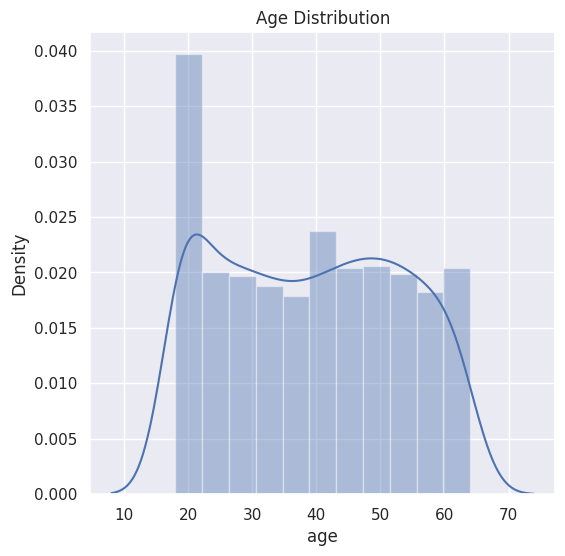

In [8]:
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(insurance_df['age'])
plt.title('Age Distribution')
plt.show()

In [83]:
plt.savefig("age_distribution.png",dpi=300,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_4617/2910562742.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex',data=insurance_df,palette='Set2')


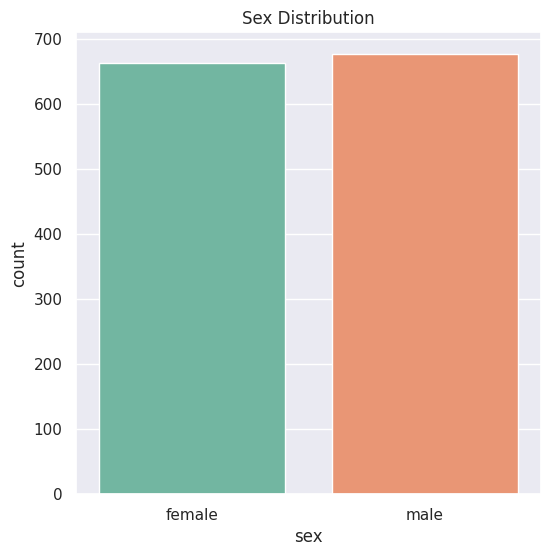

In [9]:
plt.figure(figsize=(6,6))
sns.countplot(x='sex',data=insurance_df,palette='Set2')
plt.title('Sex Distribution')
plt.show()

In [84]:
plt.savefig("sex_distribution.png",dpi=300,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [10]:
insurance_df['sex'].value_counts()

,count
sex,
male,676
female,662


/tmp/ipykernel_4617/1740320019.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_df['bmi'])


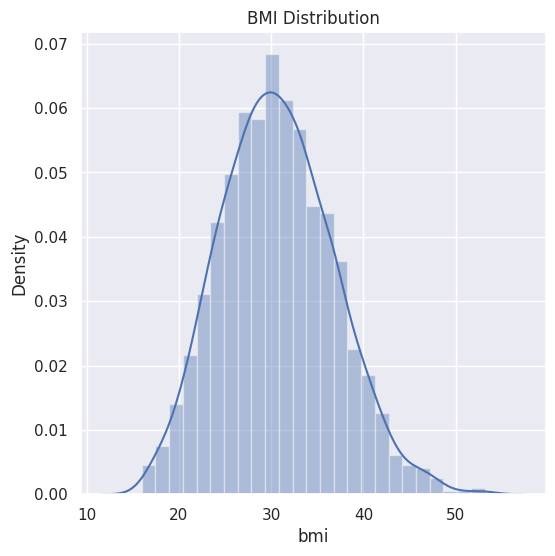

In [11]:
plt.figure(figsize=(6,6))
sns.distplot(insurance_df['bmi'])
plt.title('BMI Distribution')
plt.show()

In [85]:
plt.savefig("bmi_distribution.png",dpi=300,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Normal BMI Range ---> 18.5 to 24.9

/tmp/ipykernel_4617/1801653914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='children',data=insurance_df,palette='Set2')


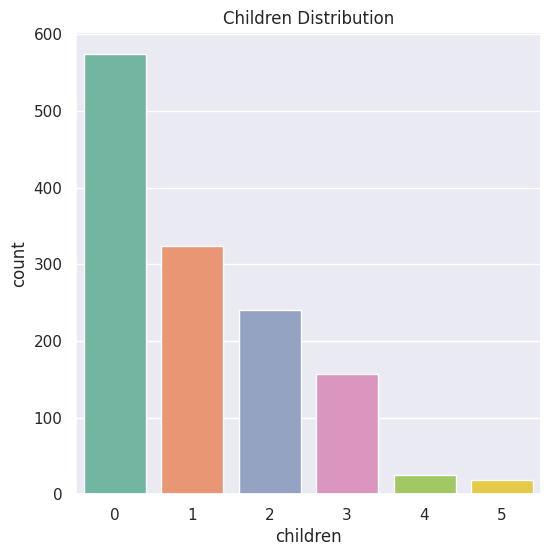

In [12]:
plt.figure(figsize=(6,6))
sns.countplot(x='children',data=insurance_df,palette='Set2')
plt.title('Children Distribution')
plt.show()

In [86]:
plt.savefig("children_distribution.png",dpi=300,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [13]:
insurance_df['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


/tmp/ipykernel_4617/3773384724.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoker',data=insurance_df,palette='Set2')


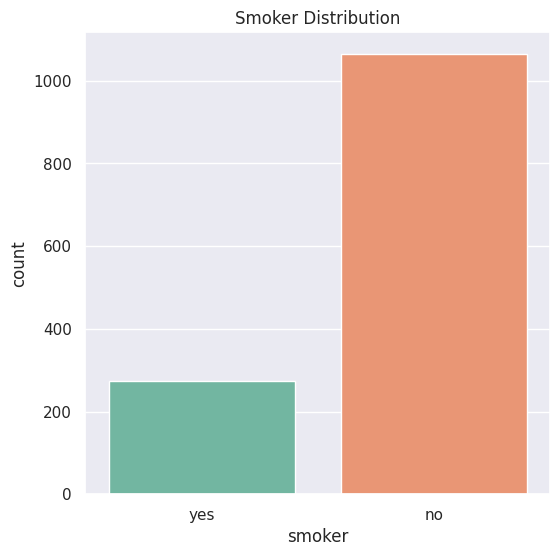

In [14]:
plt.figure(figsize=(6,6))
sns.countplot(x='smoker',data=insurance_df,palette='Set2')
plt.title('Smoker Distribution')
plt.show()

In [87]:
plt.savefig("smoker_distribution.png",dpi=300,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [15]:
insurance_df['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


/tmp/ipykernel_4617/727256617.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region',data=insurance_df,palette='Set2')


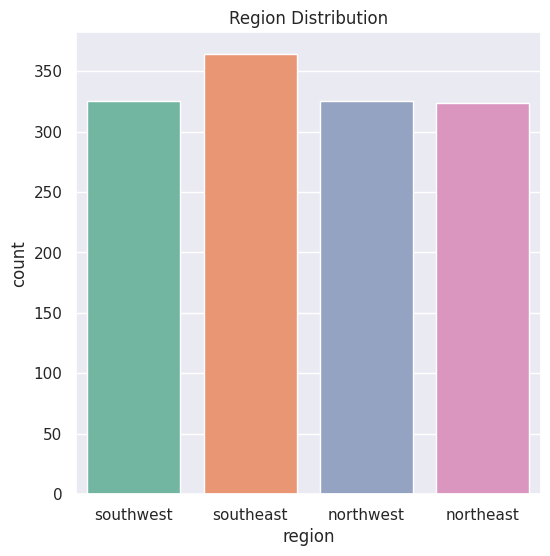

In [16]:
plt.figure(figsize=(6,6))
sns.countplot(x='region',data=insurance_df,palette='Set2')
plt.title('Region Distribution')
plt.show()

In [88]:
plt.savefig("region_distribution.png",dpi=300,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [17]:
insurance_df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


/tmp/ipykernel_4617/848087075.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_df['charges'])


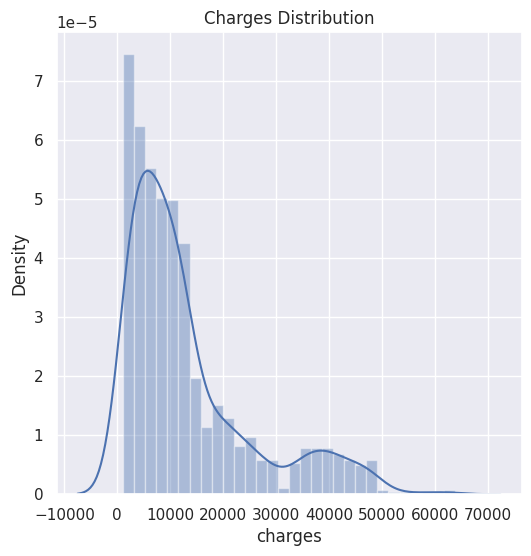

In [18]:
plt.figure(figsize=(6,6))
sns.distplot(insurance_df['charges'])
plt.title('Charges Distribution')
plt.show()

In [89]:
plt.savefig("charges_distribution.png",dpi=300,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Data Pre-Processing

Encoding the categorical features

In [19]:
insurance_df['sex'] = insurance_df['sex'].map({'male':0,'female':1})

insurance_df['smoker'] = insurance_df['smoker'].map({'yes':0,'no':1})

insurance_df['region'] = insurance_df['region'].map({'southeast':0,'southwest':1,'northeast':2,'northwest':3})

In [80]:
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520


Splitting the Features and Target

In [22]:
X = insurance_df.drop(columns='charges', axis=1)
Y = insurance_df['charges']

In [78]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,1,27.900,0,0,1
1,18,0,33.770,1,1,0
2,28,0,33.000,3,1,0
3,33,0,22.705,0,1,3
4,32,0,28.880,0,1,3


In [79]:
Y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


Splitting the data into Training data and Testing data

In [25]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [26]:
print(X.shape,X_train.shape,X_test.shape)

(1338, 6) (1070, 6) (268, 6)


Model Training

Linear Regression

In [41]:
lr = LinearRegression()

In [42]:
lr.fit(X_train,Y_train)

LinearRegression()

In [44]:
dt = DecisionTreeRegressor(random_state=2)

In [45]:
dt.fit(X_train,Y_train)

DecisionTreeRegressor(random_state=2)

In [46]:
rf = RandomForestRegressor(n_estimators=100,random_state=2)

In [47]:
rf.fit(X_train,Y_train)

RandomForestRegressor(random_state=2)

Model Prediction

In [48]:
lr_pred = lr.predict(X_test)

In [49]:
dt_pred = dt.predict(X_test)

In [50]:
rf_pred = rf.predict(X_test)

Model Evaluation

In [66]:
def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print("-"*40)
    print("MAE :", round(mae,2))
    print("RMSE :", round(rmse,2))
    print("R² Score :", round(r2,4))
    print()

In [67]:
evaluate_model("Linear Regression", Y_test, lr_pred)

evaluate_model("Decision Tree", Y_test, dt_pred)

evaluate_model("Random Forest", Y_test, rf_pred)

Linear Regression
----------------------------------------
MAE : 4267.21
RMSE : 6191.69
R² Score : 0.7447

Decision Tree
----------------------------------------
MAE : 3367.69
RMSE : 6870.84
R² Score : 0.6857

Random Forest
----------------------------------------
MAE : 2795.39
RMSE : 4947.95
R² Score : 0.837



Comparison Table

In [55]:
results = pd.DataFrame({
    'Model':['Linear Regression',
             'Decision Tree',
             'Random Forest'],

    'MAE':[
        mean_absolute_error(Y_test,lr_pred),
        mean_absolute_error(Y_test,dt_pred),
        mean_absolute_error(Y_test,rf_pred)
    ],

    'RMSE':[
        np.sqrt(mean_squared_error(Y_test,lr_pred)),
        np.sqrt(mean_squared_error(Y_test,dt_pred)),
        np.sqrt(mean_squared_error(Y_test,rf_pred))
    ],

    'R2 Score':[
        r2_score(Y_test,lr_pred),
        r2_score(Y_test,dt_pred),
        r2_score(Y_test,rf_pred)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4267.213827,6191.690842,0.744727
1,Decision Tree,3367.690489,6870.842303,0.685656
2,Random Forest,2795.391817,4947.952841,0.836982


Three regression models were trained and evaluated using MAE, RMSE, and R² Score.

Linear Regression achieved an R² Score of 0.7447, providing a strong baseline model.
Decision Tree Regressor performed worse with an R² Score of 0.6857, indicating poorer generalization.
Random Forest Regressor achieved the best performance with the highest R² Score (0.8370) and the lowest MAE and RMSE, demonstrating superior predictive accuracy.

Based on these results, Random Forest Regressor was selected
as the final model for the predictive system.

Cross Validation

In [56]:
from sklearn.model_selection import cross_val_score

In [68]:
scores = cross_val_score(rf,X,Y,cv=5,scoring='r2')
print(scores)
print("Average R2 :",scores.mean())

[0.84999603 0.78581472 0.86952762 0.83256688 0.85110463]
Average R2 : 0.8378019759722521


Feature Importance

In [69]:
importance = pd.DataFrame({'Feature':X.columns,'Importance':rf.feature_importances_})

In [70]:
importance = importance.sort_values(by='Importance',ascending=False)
importance

,Feature,Importance
4,smoker,0.627716
2,bmi,0.209551
0,age,0.124749
3,children,0.018318
5,region,0.013953
1,sex,0.005713


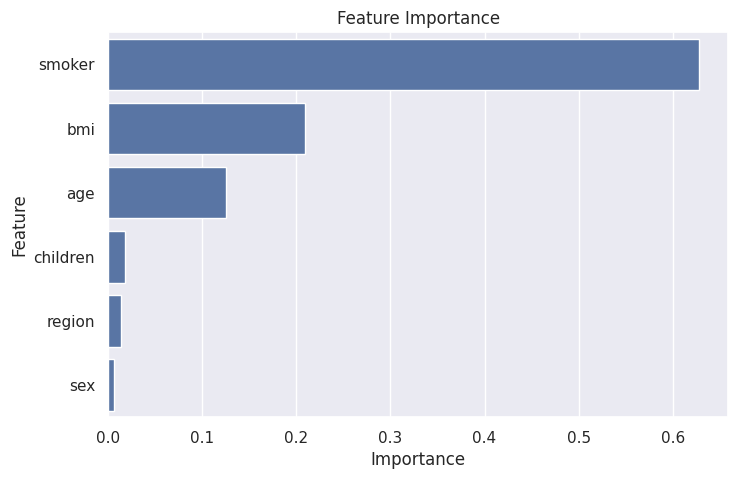

In [61]:
plt.figure(figsize=(8,5))
sns.barplot(x='Importance',y='Feature',data=importance)
plt.title("Feature Importance")
plt.show()

In [90]:
plt.savefig("feature_importance.png",dpi=300,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Residual Analysis

In [62]:
residuals = Y_test-rf_pred

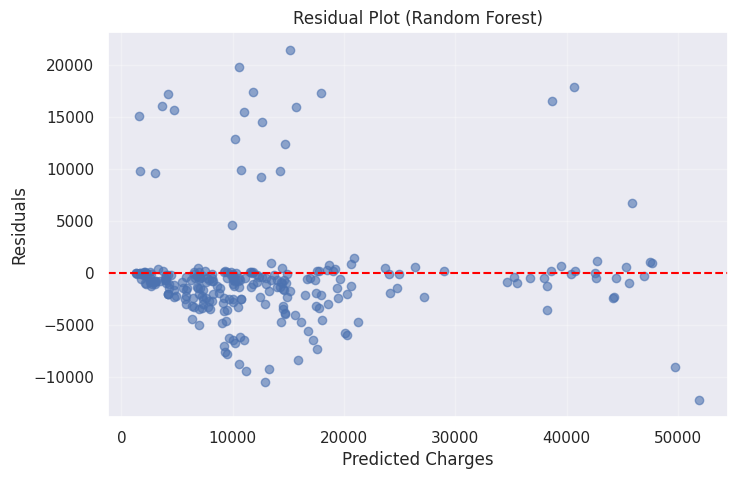

In [73]:
plt.figure(figsize=(8,5))

plt.scatter(rf_pred, residuals, alpha=0.6)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest)")

plt.grid(alpha=0.3)

plt.show()

In [91]:
plt.savefig("residual_plot.png",dpi=300,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

The residual plot illustrates the difference between the actual and predicted insurance charges. Most residuals are clustered around the zero line, indicating that the Random Forest model provides accurate predictions for the majority of observations. Although a few large positive and negative residuals are present, no clear systematic pattern is observed. This suggests that the model captures the underlying relationship in the data reasonably well while a small number of cases remain difficult to predict.

Building a predictive system

In [76]:
def predict_charge():
    age = int(input("Age: "))
    sex = int(input("Male=0 Female=1: "))
    bmi = float(input("BMI: "))
    children = int(input("Children: "))
    smoker = int(input("Smoker? Yes=0 No=1: "))
    region = int(input("Southeast=0 Southwest=1 Northeast=2 Northwest=3: "))

    data = pd.DataFrame({
        'age': [age],
        'sex': [sex],
        'bmi': [bmi],
        'children': [children],
        'smoker': [smoker],
        'region': [region]
    })

    prediction = rf.predict(data)

    print("\nPredicted Medical Insurance Charges")
    print("-----------------------------------")
    print(f"Estimated Medical Charges: ${prediction[0]:,.2f}")

In [77]:
predict_charge()

Age: 59
Male=0 Female=1: 1
BMI: 27.72
Children: 3
Smoker? Yes=0 No=1: 1
Southeast=0 Southwest=1 Northeast=2 Northwest=3: 0

Predicted Medical Insurance Charges
-----------------------------------
Estimated Medical Charges: $14,373.82


Conclusion

Three machine learning algorithms were trained and evaluated for predicting medical insurance charges. Random Forest Regressor achieved the best performance with an R² Score of approximately 0.84, outperforming Linear Regression and Decision Tree Regressor. The final predictive system successfully estimates insurance charges for new customer information, demonstrating the application of machine learning in healthcare insurance pricing.

In [92]:
import pickle

with open("insurance_models.pkl", "wb") as file:
    pickle.dump(rf, file)

print("Model saved successfully!")

Model saved successfully!


In [93]:
from google.colab import files

files.download("insurance_models.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>